In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import MinMaxScaler

In [2]:
CURRENT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(CURRENT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
CW_DIR_PATH = os.path.join(DATA_DIR_PATH, "cw")
RAW_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "raw_data")
PROCESSED_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "processed_data")

In [3]:
iea = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, 'IEA_policies_clean.csv'))
iea.head()

,year,jurisdiction,title,description,status,iso_alpha_3,country,topic,type,category
0,2011,National,Law 47-09 on Energy Efficiency,"Law 47-09, or the ""Law on Energy Efficiency"" a...",In force,MAR,Morocco,NaN,NaN,NaN
1,2017,National,Swiss Energy Strategy 2050,Swiss Energy Strategy 2050The Swiss Energy Str...,In force,CHE,Switzerland,Economy-wide,"Master Energy Plan,Framework legislation",NaN
2,2010,National,A Group of Energy Efficiency Measures in Agric...,This group consists of five PAMs.1. Biomass bo...,In force,FIN,Finland,NaN,NaN,NaN
3,1999,National,New Buses,Financial assistance to regions and municipali...,In force,ITA,Italy,NaN,NaN,NaN
4,2000,City/Municipal,New Subway System,Athens new subway system was inaugurated in Ja...,In force,GRC,Greece,NaN,NaN,NaN


In [5]:
# Check status of policies
iea['status'].unique()

array(['In force'], dtype=object)

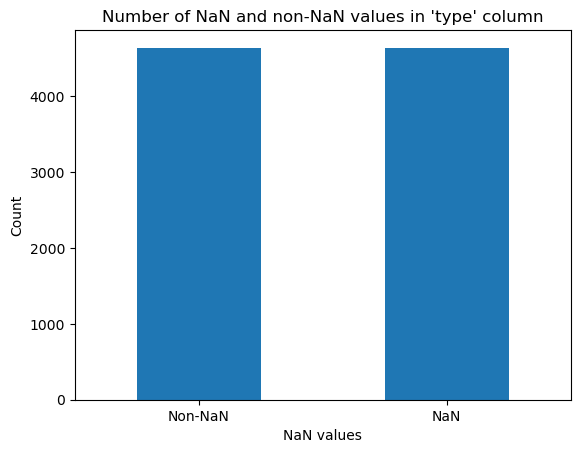

In [6]:
# Plot how many na and non-nan values in col type
iea['type'].isna().value_counts().plot(kind='bar')
plt.title("Number of NaN and non-NaN values in 'type' column")
plt.xlabel("NaN values")
plt.ylabel("Count")
plt.xticks([0, 1], ['Non-NaN', 'NaN'], rotation=0)
plt.show()

## Climate Policy Index scoring and calculating

In [8]:
# Make all text lowercase and combine title and description into one column
iea["status"] = iea["status"].str.lower()
iea["full_text"] = (iea["title"].fillna("") + " " + iea["description"].fillna("")).str.lower()
iea.head()

,year,jurisdiction,title,description,status,iso_alpha_3,country,topic,type,category,full_text
0,2011,National,Law 47-09 on Energy Efficiency,"Law 47-09, or the ""Law on Energy Efficiency"" a...",in force,MAR,Morocco,NaN,NaN,NaN,"law 47-09 on energy efficiency law 47-09, or t..."
1,2017,National,Swiss Energy Strategy 2050,Swiss Energy Strategy 2050The Swiss Energy Str...,in force,CHE,Switzerland,Economy-wide,"Master Energy Plan,Framework legislation",NaN,swiss energy strategy 2050 swiss energy strate...
2,2010,National,A Group of Energy Efficiency Measures in Agric...,This group consists of five PAMs.1. Biomass bo...,in force,FIN,Finland,NaN,NaN,NaN,a group of energy efficiency measures in agric...
3,1999,National,New Buses,Financial assistance to regions and municipali...,in force,ITA,Italy,NaN,NaN,NaN,new buses financial assistance to regions and ...
4,2000,City/Municipal,New Subway System,Athens new subway system was inaugurated in Ja...,in force,GRC,Greece,NaN,NaN,NaN,new subway system athens new subway system was...


In [9]:
iea.full_text.isna().value_counts()

full_text
False    9268
Name: count, dtype: int64

In [10]:
# Get max year
max_year = iea["year"].max()
print(f"Max year in IEA data: {max_year}")

Max year in IEA data: 2028


In [ ]:
# Expand 'in force' policies for every year until 2022 (If it finds a policy in force, it will add it for every year until 2022)
expanded_rows = []
for _, row in iea.iterrows():
    if row["status"] == "in force":
        for year in range(int(row["year"]), max_year + 1):
            new_row = row.copy()
            new_row["year"] = year
            expanded_rows.append(new_row)
    elif row["status"] == "ended": # if the policy is ended, it will only be added for the year it was created
        expanded_rows.append(row)


iea = pd.DataFrame(expanded_rows)

,year,jurisdiction,title,description,status,iso_alpha_3,country,topic,type,category,full_text
0,1948,National,Oilfields (Regulation and Development) Act 1948,"This states that Central Government may, by pr...",in force,IND,India,NaN,NaN,NaN,oilfields (regulation and development) act 194...
1,1949,National,Oilfields (Regulation and Development) Act 1948,"This states that Central Government may, by pr...",in force,IND,India,NaN,NaN,NaN,oilfields (regulation and development) act 194...
2,1950,National,Oilfields (Regulation and Development) Act 1948,"This states that Central Government may, by pr...",in force,IND,India,NaN,NaN,NaN,oilfields (regulation and development) act 194...
3,1951,National,Oilfields (Regulation and Development) Act 1948,"This states that Central Government may, by pr...",in force,IND,India,NaN,NaN,NaN,oilfields (regulation and development) act 194...
4,1951,National,Electricity tax,"Introduced in 1951, an electricity tax has bee...",in force,NOR,Norway,NaN,NaN,NaN,"electricity tax introduced in 1951, an electri..."


In [13]:
iea = iea.sort_values(by=["iso_alpha_3", "year"]).reset_index(drop=True)
iea.head()

,year,jurisdiction,title,description,status,iso_alpha_3,country,topic,type,category,full_text
0,1971,International,EU Generalised Scheme of Preferences,The EU Generalised Scheme of Preferences (GSP)...,in force,AFG,Afghanistan,"Transport,Buildings,Power","Free trade agreement,Trade policies","Heat pumps,Electric light-duty vehicles,Batter...",eu generalised scheme of preferences the eu ge...
1,1972,International,EU Generalised Scheme of Preferences,The EU Generalised Scheme of Preferences (GSP)...,in force,AFG,Afghanistan,"Transport,Buildings,Power","Free trade agreement,Trade policies","Heat pumps,Electric light-duty vehicles,Batter...",eu generalised scheme of preferences the eu ge...
2,1973,International,EU Generalised Scheme of Preferences,The EU Generalised Scheme of Preferences (GSP)...,in force,AFG,Afghanistan,"Transport,Buildings,Power","Free trade agreement,Trade policies","Heat pumps,Electric light-duty vehicles,Batter...",eu generalised scheme of preferences the eu ge...
3,1974,International,EU Generalised Scheme of Preferences,The EU Generalised Scheme of Preferences (GSP)...,in force,AFG,Afghanistan,"Transport,Buildings,Power","Free trade agreement,Trade policies","Heat pumps,Electric light-duty vehicles,Batter...",eu generalised scheme of preferences the eu ge...
4,1975,International,EU Generalised Scheme of Preferences,The EU Generalised Scheme of Preferences (GSP)...,in force,AFG,Afghanistan,"Transport,Buildings,Power","Free trade agreement,Trade policies","Heat pumps,Electric light-duty vehicles,Batter...",eu generalised scheme of preferences the eu ge...


In [ ]:
### ! Alternate IEA dataframe without expanding policies for subsequent years + without ended

#iea = pd.read_csv("/Users/cynthiasalinas/Documents/econ_climate/important/IEA_policies_raw.csv", encoding="ISO-8859-1")
#iea = iea[iea["status"].str.lower() == "in force"]
#iea = iea[(iea["year"] >= 2000) & (iea["year"] <= 2022)].copy()
#iea["full_text"] = (iea["title"].fillna("") + " " + iea["description"].fillna("")).str.lower()


In [14]:
#Type & Category Mappings
type_mapping = pd.read_csv(os.path.join(CW_DIR_PATH, "Type_C-Level_Mapping.csv"))
category_mapping = pd.read_csv(os.path.join(CW_DIR_PATH, "Category_Theme_Mapping.csv"))
topic_mapping = pd.read_csv(os.path.join(CW_DIR_PATH, "Topic_Theme_Mapping.csv"))

# Dictionaries for mappings
type_dict = dict(zip(type_mapping['type'], type_mapping['C_level']))
topic_dict = dict(zip(topic_mapping['topic'], topic_mapping['topic_theme_14_refined']))
category_dict = dict(zip(category_mapping['category'], category_mapping['category_theme_27']))

In [15]:
# Define NLP keywords for C1-C4 categories

keywords = {
    'C1': ['ban', 'banned', 'banning', 'prohibit', 'prohibition', 'restriction', 'restricted', 'mandate', 'mandatory', 'outlawed', 'phase-out', 'elimination', 'forbidden', 'sales ban', 'exploration ban'],
    'C2': ['tax', 'levy', 'pricing', 'carbon pricing', 'fuel tax', 'tariff', 'subsidy removal'],
    'C3': ['standard', 'performance', 'emissions limit', 'efficiency code', 'compliance', 'emissions cap', 'minimum standard', 'permitting'],
    'C4': ['grant', 'funding', 'finance', 'subsidy', 'support', 'r&d', 'research', 'development', 'information', 'education', 'training', 'capacity-building', 'knowledge', 'awareness', 'incentives', 'investment', 'pilot program', 'dialogue', 'workshops', 'partnership']
}

# NLP-based scoring function
def nlp_score(row):
    text = ' '.join([str(row['topic']), str(row['description'])]).lower()
    for level, words in keywords.items():
        if any(word in text for word in words):
            return {'C1': 1.0, 'C2': 0.75, 'C3': 0.5, 'C4': 0.25}[level]
    return 0.25

# Assign C-level scores based on type
def type_score(row):
    if pd.notna(row['type']):
        mapping = type_mapping[type_mapping['type'] == row['type']]
        if not mapping.empty:
            level = mapping.iloc[0]['C_level']
            return {'C1': 1.0, 'C2': 0.75, 'C3': 0.5, 'C4': 0.25}[level]
    return None

# Apply scoring logic clearly
# iea['score_type'] = iea.apply(type_score, axis=1)
iea['score_nlp'] = iea.apply(nlp_score, axis=1)
# iea['final_score'] = iea[['score_type', 'score_nlp']].max(axis=1) # Final score is the maximum of type and NLP scores

# Direct assignment
iea['topic_theme_14_refined'] = iea['topic'].map(topic_dict).fillna('Other')
iea['category_theme_27'] = iea['category'].map(category_dict).fillna('Other')

# Scored policies dataframe
iea_scored_policies = iea[['country', 'iso_alpha_3', 'year', 'jurisdiction', 'type', 'topic', 'description', 'category',
                           'score_nlp', 'topic_theme_14_refined', 'category_theme_27']]
iea_scored_policies.head()

,country,iso_alpha_3,year,jurisdiction,type,topic,description,category,score_nlp,topic_theme_14_refined,category_theme_27
0,Afghanistan,AFG,1971,International,"Free trade agreement,Trade policies","Transport,Buildings,Power",The EU Generalised Scheme of Preferences (GSP)...,"Heat pumps,Electric light-duty vehicles,Batter...",0.75,Energy,Solar Power
1,Afghanistan,AFG,1972,International,"Free trade agreement,Trade policies","Transport,Buildings,Power",The EU Generalised Scheme of Preferences (GSP)...,"Heat pumps,Electric light-duty vehicles,Batter...",0.75,Energy,Solar Power
2,Afghanistan,AFG,1973,International,"Free trade agreement,Trade policies","Transport,Buildings,Power",The EU Generalised Scheme of Preferences (GSP)...,"Heat pumps,Electric light-duty vehicles,Batter...",0.75,Energy,Solar Power
3,Afghanistan,AFG,1974,International,"Free trade agreement,Trade policies","Transport,Buildings,Power",The EU Generalised Scheme of Preferences (GSP)...,"Heat pumps,Electric light-duty vehicles,Batter...",0.75,Energy,Solar Power
4,Afghanistan,AFG,1975,International,"Free trade agreement,Trade policies","Transport,Buildings,Power",The EU Generalised Scheme of Preferences (GSP)...,"Heat pumps,Electric light-duty vehicles,Batter...",0.75,Energy,Solar Power


In [16]:
carbon_pricing_df = iea_scored_policies[iea_scored_policies['type'].notna() & iea_scored_policies['type'].str.contains('carbon pricing instruments', case=False, na=False)]
carbon_pricing_df.head()

,country,iso_alpha_3,year,jurisdiction,type,topic,description,category,score_nlp,topic_theme_14_refined,category_theme_27
2378,Argentina,ARG,2018,National,"Carbon pricing instruments,Regulations","Transport,Buildings,Industry,Power",The government of Argentina implemented a carb...,Carbon tax,1.0,Industry,Carbon Pricing
2430,Argentina,ARG,2019,National,"Carbon pricing instruments,Regulations","Transport,Buildings,Industry,Power",The government of Argentina implemented a carb...,Carbon tax,1.0,Industry,Carbon Pricing
2470,Argentina,ARG,2020,National,"Carbon pricing instruments,Regulations","Transport,Buildings,Industry,Power",The government of Argentina implemented a carb...,Carbon tax,1.0,Industry,Carbon Pricing
2577,Argentina,ARG,2021,National,"Carbon pricing instruments,Regulations","Transport,Buildings,Industry,Power",The government of Argentina implemented a carb...,Carbon tax,1.0,Industry,Carbon Pricing
2654,Argentina,ARG,2022,National,"Carbon pricing instruments,Regulations","Transport,Buildings,Industry,Power",The government of Argentina implemented a carb...,Carbon tax,1.0,Industry,Carbon Pricing


In [17]:
iea_scored_policies[iea_scored_policies['category_theme_27'] == 'Carbon Pricing']

,country,iso_alpha_3,year,jurisdiction,type,topic,description,category,score_nlp,topic_theme_14_refined,category_theme_27
2378,Argentina,ARG,2018,National,"Carbon pricing instruments,Regulations","Transport,Buildings,Industry,Power",The government of Argentina implemented a carb...,Carbon tax,1.00,Industry,Carbon Pricing
2430,Argentina,ARG,2019,National,"Carbon pricing instruments,Regulations","Transport,Buildings,Industry,Power",The government of Argentina implemented a carb...,Carbon tax,1.00,Industry,Carbon Pricing
2470,Argentina,ARG,2020,National,"Carbon pricing instruments,Regulations","Transport,Buildings,Industry,Power",The government of Argentina implemented a carb...,Carbon tax,1.00,Industry,Carbon Pricing
2577,Argentina,ARG,2021,National,"Carbon pricing instruments,Regulations","Transport,Buildings,Industry,Power",The government of Argentina implemented a carb...,Carbon tax,1.00,Industry,Carbon Pricing
2654,Argentina,ARG,2022,National,"Carbon pricing instruments,Regulations","Transport,Buildings,Industry,Power",The government of Argentina implemented a carb...,Carbon tax,1.00,Industry,Carbon Pricing
...,...,...,...,...,...,...,...,...,...,...,...
148652,South Africa,ZAF,2024,National,"Carbon pricing instruments,Regulations","Buildings,Industry,Power","The Carbon Tax Act, enacted in June 2019, give...",Carbon tax,0.75,Industry,Carbon Pricing
148773,South Africa,ZAF,2025,National,"Carbon pricing instruments,Regulations","Buildings,Industry,Power","The Carbon Tax Act, enacted in June 2019, give...",Carbon tax,0.75,Industry,Carbon Pricing
148958,South Africa,ZAF,2026,National,"Carbon pricing instruments,Regulations","Buildings,Industry,Power","The Carbon Tax Act, enacted in June 2019, give...",Carbon tax,0.75,Industry,Carbon Pricing
149096,South Africa,ZAF,2027,National,"Carbon pricing instruments,Regulations","Buildings,Industry,Power","The Carbon Tax Act, enacted in June 2019, give...",Carbon tax,0.75,Industry,Carbon Pricing


In [18]:
# rename score_nlp col to policy_score
iea_scored_policies = iea_scored_policies.rename(columns={'score_nlp': 'policy_score'})

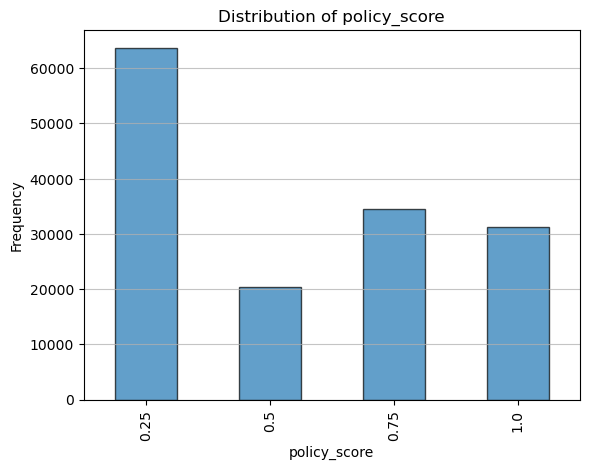

In [19]:
iea_scored_policies['policy_score'].value_counts().sort_index().plot(kind='bar', edgecolor='black', alpha=0.7)
plt.title('Distribution of policy_score')
plt.xlabel('policy_score')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [20]:
# How many policies each country has?
policies_per_country_df = iea_scored_policies['iso_alpha_3'].value_counts().reset_index()
policies_per_country_df.columns = ['iso_alpha_3', 'policy_count']
policies_per_country_df.head()

,iso_alpha_3,policy_count
0,USA,10725
1,CAN,4992
2,AUS,4691
3,DEU,4288
4,EUR,4033


In [21]:
policies_per_country_df.tail(120)

,iso_alpha_3,policy_count
96,SLV,331
97,ZMB,328
98,BGR,320
99,SEN,317
100,LSO,294
...,...,...
211,ESH,10
212,SMR,8
213,PLW,8
214,VAT,8


In [22]:
oecd_countries_iso3 = [
    "AUS",  # Australia
    "AUT",  # Austria
    "BEL",  # Belgium
    "CAN",  # Canada
    "CHL",  # Chile
    "COL",  # Colombia
    "CZE",  # Czech Republic
    "DNK",  # Denmark
    "EST",  # Estonia
    "FIN",  # Finland
    "FRA",  # France
    "DEU",  # Germany
    "GRC",  # Greece
    "HUN",  # Hungary
    "ISL",  # Iceland
    "IRL",  # Ireland
    "ISR",  # Israel
    "ITA",  # Italy
    "JPN",  # Japan
    "KOR",  # South Korea
    "LVA",  # Latvia
    "LTU",  # Lithuania
    "LUX",  # Luxembourg
    "MEX",  # Mexico
    "NLD",  # Netherlands
    "NZL",  # New Zealand
    "NOR",  # Norway
    "POL",  # Poland
    "PRT",  # Portugal
    "SVK",  # Slovakia
    "SVN",  # Slovenia
    "ESP",  # Spain
    "SWE",  # Sweden
    "CHE",  # Switzerland
    "TUR",  # Turkey
    "GBR",  # United Kingdom
    "USA"   # United States
]

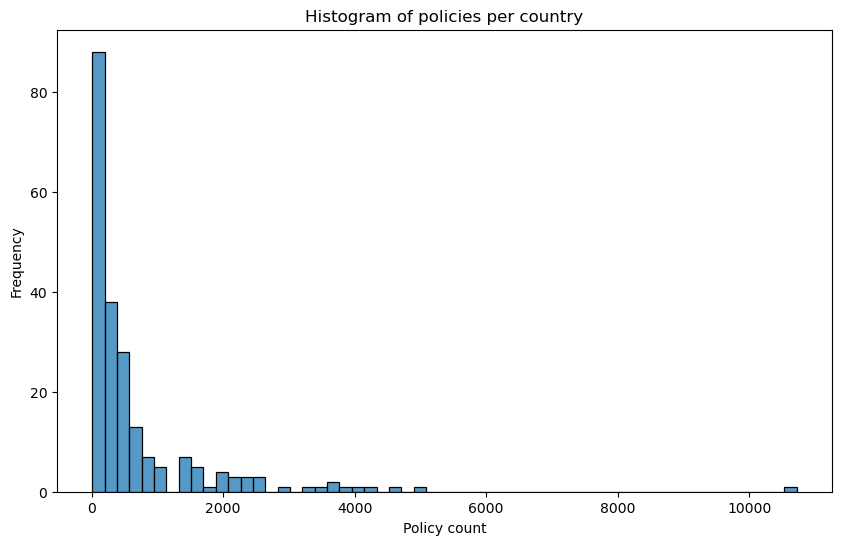

In [23]:
def plot_histogram_of_policies(policies_df):
    """
    Plots a histogram of policy counts per country.

    Parameters:
    policies_df (pd.DataFrame): DataFrame containing 'policy_count' column.

    Returns:
    None
    """
    plt.figure(figsize=(10, 6))
    sns.histplot(policies_df['policy_count'])
    plt.title('Histogram of policies per country')
    plt.xlabel('Policy count')
    plt.ylabel('Frequency')
    plt.show()

plot_histogram_of_policies(policies_per_country_df)


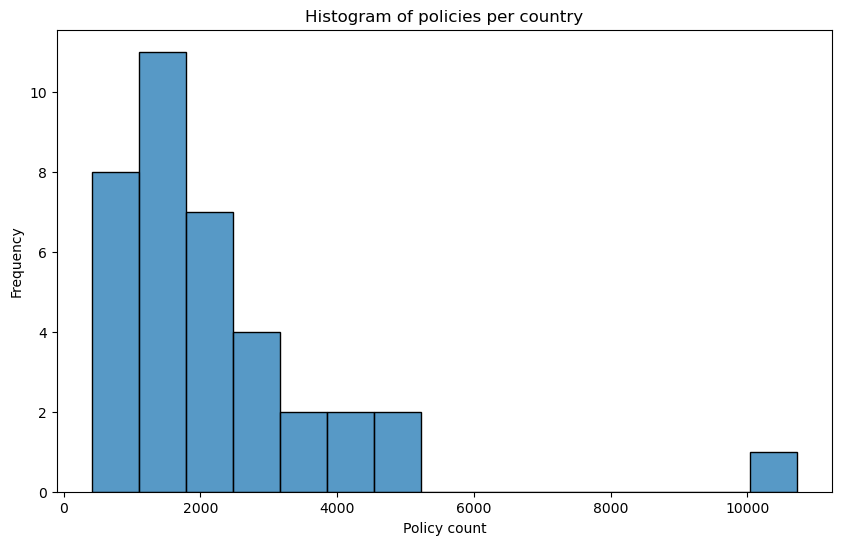

In [24]:
plot_histogram_of_policies(policies_per_country_df[policies_per_country_df.iso_alpha_3.isin(oecd_countries_iso3)])

In [30]:
iea_scored_cpsi = iea_scored_policies.groupby(['iso_alpha_3', 'year']).agg(
    avg_policy_score=('policy_score', 'mean'),
    policy_count=('policy_score', 'count'),
    dominant_topic=('topic_theme_14_refined', lambda x: x.mode()[0] if not x.isna().all() else np.nan),
    dominant_category=('category_theme_27', lambda x: x.mode()[0] if not x.isna().all() else np.nan)
).reset_index()

# add log policy count term
iea_scored_cpsi['log_policy_count'] = np.log1p(iea_scored_cpsi['policy_count'])

# Composite index: average score *  log of policy count
iea_scored_cpsi['policy_index'] = iea_scored_cpsi['avg_policy_score'] *  iea_scored_cpsi['log_policy_count']


iea_scored_cpsi.head()


,iso_alpha_3,year,avg_policy_score,policy_count,dominant_topic,dominant_category,log_policy_count,policy_index
0,AFG,1971,0.75,1,Energy,Solar Power,0.693147,0.51986
1,AFG,1972,0.75,1,Energy,Solar Power,0.693147,0.51986
2,AFG,1973,0.75,1,Energy,Solar Power,0.693147,0.51986
3,AFG,1974,0.75,1,Energy,Solar Power,0.693147,0.51986
4,AFG,1975,0.75,1,Energy,Solar Power,0.693147,0.51986


In [31]:
iea_scored_cpsi[iea_scored_cpsi['iso_alpha_3'] == 'CHE'].tail()

,iso_alpha_3,year,avg_policy_score,policy_count,dominant_topic,dominant_category,log_policy_count,policy_index
1417,CHE,2024,0.636842,95,Cross-cutting / Economy-wide,Other,4.564348,2.906769
1418,CHE,2025,0.636842,95,Cross-cutting / Economy-wide,Other,4.564348,2.906769
1419,CHE,2026,0.636842,95,Cross-cutting / Economy-wide,Other,4.564348,2.906769
1420,CHE,2027,0.636842,95,Cross-cutting / Economy-wide,Other,4.564348,2.906769
1421,CHE,2028,0.636842,95,Cross-cutting / Economy-wide,Other,4.564348,2.906769


In [32]:
iea_scored_cpsi[iea_scored_cpsi['iso_alpha_3'] == 'USA'].tail()

,iso_alpha_3,year,avg_policy_score,policy_count,dominant_topic,dominant_category,log_policy_count,policy_index
8756,USA,2024,0.483670,643,Cross-cutting / Economy-wide,Other,6.467699,3.128234
8757,USA,2025,0.483670,643,Cross-cutting / Economy-wide,Other,6.467699,3.128234
8758,USA,2026,0.483670,643,Cross-cutting / Economy-wide,Other,6.467699,3.128234
8759,USA,2027,0.483721,645,Cross-cutting / Economy-wide,Other,6.470800,3.130061
8760,USA,2028,0.483721,645,Cross-cutting / Economy-wide,Other,6.470800,3.130061


In [33]:
iea_scored_cpsi[iea_scored_cpsi['iso_alpha_3'] == 'BMU']

,iso_alpha_3,year,avg_policy_score,policy_count,dominant_topic,dominant_category,log_policy_count,policy_index
954,BMU,2014,1.0,1,Energy,Solar Power,0.693147,0.693147
955,BMU,2015,1.0,1,Energy,Solar Power,0.693147,0.693147
956,BMU,2016,1.0,1,Energy,Solar Power,0.693147,0.693147
957,BMU,2017,1.0,1,Energy,Solar Power,0.693147,0.693147
958,BMU,2018,1.0,1,Energy,Solar Power,0.693147,0.693147
959,BMU,2019,1.0,1,Energy,Solar Power,0.693147,0.693147
960,BMU,2020,1.0,1,Energy,Solar Power,0.693147,0.693147
961,BMU,2021,1.0,1,Energy,Solar Power,0.693147,0.693147
962,BMU,2022,1.0,1,Energy,Solar Power,0.693147,0.693147
963,BMU,2023,1.0,1,Energy,Solar Power,0.693147,0.693147


In [36]:
# Create a df with the avg avg_policy_score and avg_policy_count for each country
iea_scored_cpsi_avg = iea_scored_cpsi.groupby('iso_alpha_3').agg(
    avg_policy_score=('avg_policy_score', 'mean'),
    avg_policy_count=('policy_count', 'mean'),
    avg_policy_index=('policy_index', 'mean')
).reset_index()
iea_scored_cpsi_avg = iea_scored_cpsi_avg.sort_values(by='avg_policy_score', ascending=False)
iea_scored_cpsi_avg.head(20)

,iso_alpha_3,avg_policy_score,avg_policy_count,avg_policy_index
81,GUF,1.000000,1.000000,0.693147
65,FLK,1.000000,1.000000,0.693147
46,CYM,1.000000,1.000000,0.693147
153,PCN,1.000000,1.000000,0.693147
4,ANT,1.000000,1.000000,0.693147
90,IOT,1.000000,1.000000,0.693147
210,WLF,1.000000,1.000000,0.693147
24,BMU,1.000000,1.000000,0.693147
8,ATF,1.000000,1.000000,0.693147
163,PYF,1.000000,1.000000,0.693147


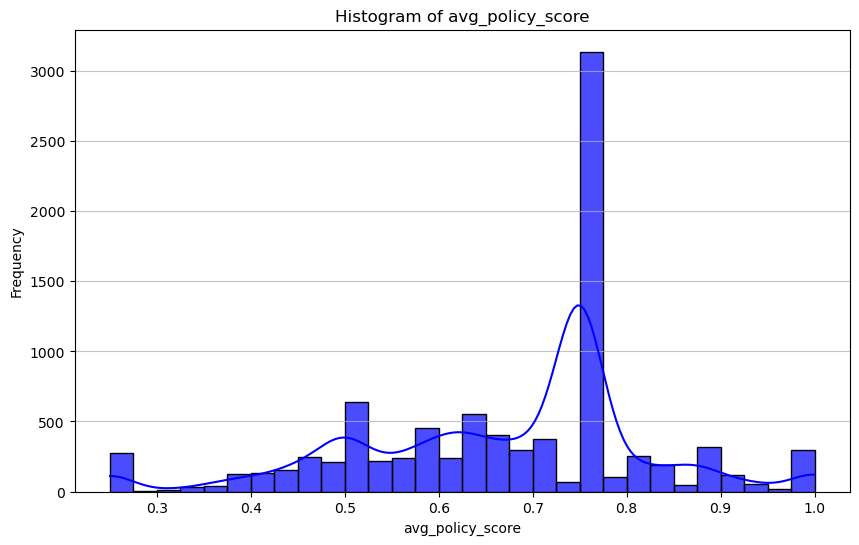

In [37]:
plt.figure(figsize=(10, 6))
sns.histplot(iea_scored_cpsi['avg_policy_score'], bins=30, kde=True, color='blue', alpha=0.7)
plt.title('Histogram of avg_policy_score')
plt.xlabel('avg_policy_score')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

## Tunning the index

In [39]:
def plot_index_and_policy_trend(df, countries, index_col='policy_index', policy_count_col='policy_count', year_col='year', show_policy_count=False, quartiles=False):
    """
    Plots policy index and policy count trends for selected countries.

    Parameters:
    df (pd.DataFrame): DataFrame containing policy index and policy count data.
    countries (list): List of country ISO alpha-3 codes to include in the plot.
    index_col (str): Column name for policy index values.
    policy_count_col (str): Column name for policy count values.
    year_col (str): Column name for year values.
    show_policy_count (bool): Whether to include the secondary axis for policy count.

    Returns:
    None
    """
    # Filter data for the selected countries
    filtered_data = df[df['iso_alpha_3'].isin(countries)]

    # Plotting
    plt.figure(figsize=(14, 8))

    # Set up main axis
    ax1 = plt.gca()

    # Plot CPSI trend
    for country in countries:
        country_data = filtered_data[filtered_data['iso_alpha_3'] == country].sort_values(year_col)
        cpsi_smoothed = country_data.set_index(year_col)[index_col].rolling(window=2, min_periods=1).mean()
        ax1.plot(cpsi_smoothed.index, cpsi_smoothed.values, label=f'{country} (Policy Index)', linewidth=2.5)

    if quartiles:

        # Calculate quartiles
        q1 = filtered_data[index_col].quantile(0.25)
        q2 = filtered_data[index_col].quantile(0.50)  # Median
        q3 = filtered_data[index_col].quantile(0.75)

        # Plot quartile lines
        ax1.axhline(q1, color='red', linestyle='--', linewidth=1.5, label=f'Q1: {q1:.2f}')
        ax1.axhline(q2, color='red', linestyle='--', linewidth=1.5, label=f'Q2 (Median): {q2:.2f}')
        ax1.axhline(q3, color='red', linestyle='--', linewidth=1.5, label=f'Q3: {q3:.2f}')

    ax1.set_ylabel(index_col, fontsize=12)
    ax1.set_xlabel('Year')
    ax1.set_title(f'{index_col} vs Policy Count Over Time – Selected Countries', fontsize=16)
    ax1.grid(alpha=0.3)

    if show_policy_count:
        # Secondary Y-axis for policy count
        ax2 = ax1.twinx()
        for country in countries:
            country_data = filtered_data[filtered_data['iso_alpha_3'] == country].sort_values(year_col)
            ax2.plot(country_data[year_col], country_data[policy_count_col], linestyle='--', alpha=0.5, label=f'{country} (Policies)')

        ax2.set_ylabel('Number of Policies', fontsize=12)
        ax2.set_ylim(0, filtered_data[policy_count_col].max() + 5)

        # Combine legends
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
    else:
        # Legend for CPSI only
        ax1.legend(loc='upper left', fontsize=9)

    plt.tight_layout()
    plt.show()

In [40]:
# ------------------------------------------------------------------
# 1. Log-scaling, up-weighted by a constant α
# ------------------------------------------------------------------
def policy_index_log_alpha(df, *, alpha=2.0,
                   score_col='avg_policy_score',
                   count_col='policy_count'):
    """
    Policy Index = avg_score × α × ln(1 + n)
    """
    log_term = alpha * np.log1p(df[count_col])
    return df[score_col] * log_term


# ------------------------------------------------------------------
# 2. Box–Cox-style power transform with exponent θ (0<θ<1)
# ------------------------------------------------------------------
def policy_index_power(df, *, theta=0.4,
               score_col='avg_policy_score',
               count_col='policy_count'):
    """
    Policy Index = avg_score × [(1+n)^θ – 1] / θ
    θ→0 reproduces the log; θ→1 approaches linear.
    """
    n_pow = ((1 + df[count_col]) ** theta - 1) / theta
    return df[score_col] * n_pow


# ------------------------------------------------------------------
# 3. Weighted sum after min–max scaling (explicit trade-off)
# ------------------------------------------------------------------
def policy_index_weighted(df, *, w_score=0.6, w_count=0.4,
                  score_col='avg_policy_score',
                  count_col='policy_count'):
    """
    Policy Index = w_s × scaled(avg_score) + w_c × scaled(count)
    Both components are on [0,1] after min–max scaling.
    """
    mm = MinMaxScaler()
    score_scaled = mm.fit_transform(df[[score_col]]).squeeze()
    count_scaled = mm.fit_transform(df[[count_col]]).squeeze()
    return w_score * score_scaled + w_count * count_scaled


# ------------------------------------------------------------------
# 4. Geometric mean with tunable elasticities α, β
# ------------------------------------------------------------------
def policy_index_geom(df, *, alpha=0.5, beta=0.5,
              score_col='avg_policy_score',
              count_col='policy_count'):
    """
    Policy Index = (avg_score)^β × (1 + n)^α
    """
    return (df[score_col] ** beta) * ((1 + df[count_col]) ** alpha)


# ------------------------------------------------------------------
# 5. Piece-wise (linear → √) scaling to curb runaway counts
# ------------------------------------------------------------------
def policy_index_piecewise(df, *, cutoff=20,
                   score_col='avg_policy_score',
                   count_col='policy_count'):
    """
    If n ≤ cutoff:          count_adj = n
    If n  > cutoff:         count_adj = cutoff + √(n − cutoff)
    Policy Index = avg_score × count_adj
    """
    n = df[count_col].values
    count_adj = np.where(n <= cutoff, n, cutoff + np.sqrt(n - cutoff))
    return df[score_col] * count_adj


# ---------------------------------------------------------------
# ---- Example usage -------------------------------------------
# ---------------------------------------------------------------
# Add a Policy Index column for each variant so you can compare them side-by-side
# iea_scored_cpsi['policy_index_log_alpha']  = policy_index_log_alpha(iea_scored_cpsi, alpha=3.0)
# iea_scored_cpsi['policy_index_power']      = policy_index_power(iea_scored_cpsi, theta=0.4)
# iea_scored_cpsi['policy_index_power_2']   = policy_index_power(iea_scored_cpsi, theta=0.2)
# iea_scored_cpsi['policy_index_power_3']   = policy_index_power(iea_scored_cpsi, theta=0.6)
# iea_scored_cpsi['policy_index_weighted']   = policy_index_weighted(iea_scored_cpsi, w_score=0.6, w_count=0.4) 
# iea_scored_cpsi['policy_index_geom']       = policy_index_geom(iea_scored_cpsi, alpha=0.6, beta=0.4)
# iea_scored_cpsi['policy_index_geom_2']     = policy_index_geom(iea_scored_cpsi, alpha=0.4, beta=0.6)
# iea_scored_cpsi['policy_index_geom_3']     = policy_index_geom(iea_scored_cpsi, alpha=0.5, beta=0.5)
# iea_scored_cpsi['policy_index_geom_4']     = policy_index_geom(iea_scored_cpsi, alpha=0.7, beta=0.3)
# iea_scored_cpsi['policy_index_geom_5']     = policy_index_geom(iea_scored_cpsi, alpha=0.3, beta=0.7)
# iea_scored_cpsi['policy_index_geom_6']     = policy_index_geom(iea_scored_cpsi, alpha=0.1, beta=0.9)
iea_scored_cpsi['policy_index_geom_7']     = policy_index_geom(iea_scored_cpsi, alpha=0.2, beta=0.8)
# iea_scored_cpsi['policy_index_piecewise']  = policy_index_piecewise(iea_scored_cpsi, cutoff=20)

In [41]:
iea_scored_cpsi.head()

,iso_alpha_3,year,avg_policy_score,policy_count,dominant_topic,dominant_category,log_policy_count,policy_index,policy_index_geom_7
0,AFG,1971,0.75,1,Energy,Solar Power,0.693147,0.51986,0.912547
1,AFG,1972,0.75,1,Energy,Solar Power,0.693147,0.51986,0.912547
2,AFG,1973,0.75,1,Energy,Solar Power,0.693147,0.51986,0.912547
3,AFG,1974,0.75,1,Energy,Solar Power,0.693147,0.51986,0.912547
4,AFG,1975,0.75,1,Energy,Solar Power,0.693147,0.51986,0.912547


In [42]:
def _default_index_cols(df, index_cols):
    if index_cols is not None:
        return index_cols
    # pick every column whose name starts with "policy_index"
    return [c for c in df.columns if c.lower().startswith("policy_index")]

def plot_policy_index_histograms(df, index_cols=None, bins=30, figsize=(12, 2.5)):
    """
    One histogram per policy_index variant (small-multiples layout).
    """
    cols = _default_index_cols(df, index_cols)
    n     = len(cols)
    fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(figsize[0], figsize[1]*n), sharex=False)

    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, cols):
        ax.hist(df[col].dropna(), bins=bins, alpha=0.7)
        ax.set_title(f'Histogram: {col}')
        ax.set_ylabel('Freq.')

    axes[-1].set_xlabel('policy_index value')
    fig.tight_layout()
    plt.show()

def plot_policy_index_kde(df, index_cols=None, figsize=(10, 6)):
    """
    Overlays kernel-density curves for all policy_index variants in a single plot.
    """
    cols = _default_index_cols(df, index_cols)
    plt.figure(figsize=figsize)

    for col in cols:
        sns.kdeplot(df[col].dropna(), label=col, linewidth=1.7)

    plt.title('policy_index variants – KDE overlay')
    plt.legend()
    plt.xlabel('policy_index value')
    plt.ylabel('Density')
    plt.ylim(0, 5)
    plt.xlim(0, 5)
    plt.show()

def plot_policy_index_boxplot(df, index_cols=None, figsize=(10, 5)):
    """
    Shows spread & outliers side-by-side across policy_index variants.
    """
    cols = _default_index_cols(df, index_cols)
    plt.figure(figsize=figsize)
    sns.boxplot(data=df[cols], orient='h', showfliers=True)
    plt.title('policy_index variants – box-plot comparison')
    plt.xlabel('policy_index value')
    plt.yticks(rotation=0)
    plt.show()

def compare_policy_index_distributions(df, index_cols=None, bins=30):
    """
    Quick exploratory combo: histograms, KDE overlay, and box-plot.
    """
    plot_policy_index_histograms(df, index_cols=index_cols, bins=bins)
    plot_policy_index_kde(df, index_cols=index_cols)
    plot_policy_index_boxplot(df, index_cols=index_cols)


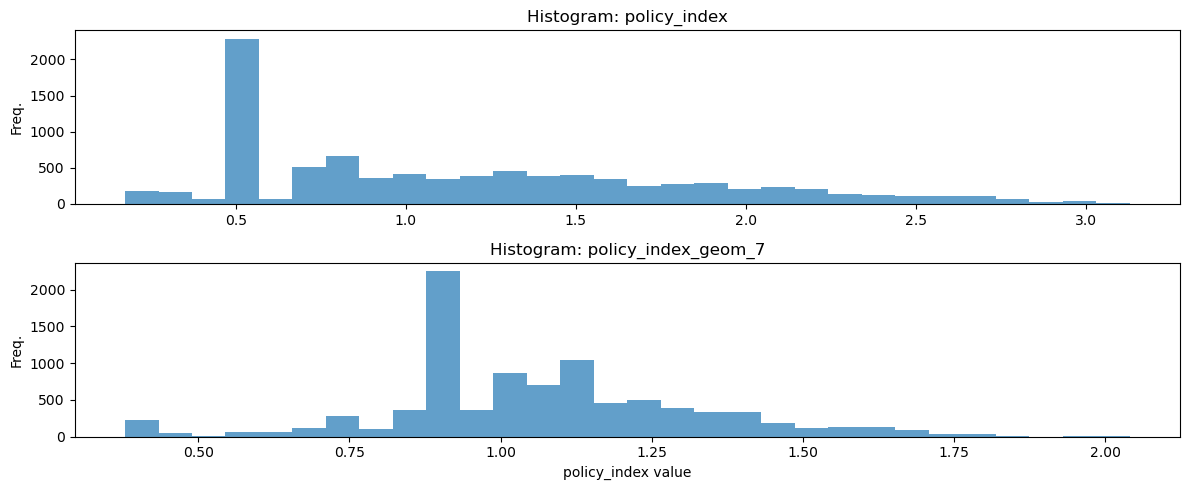

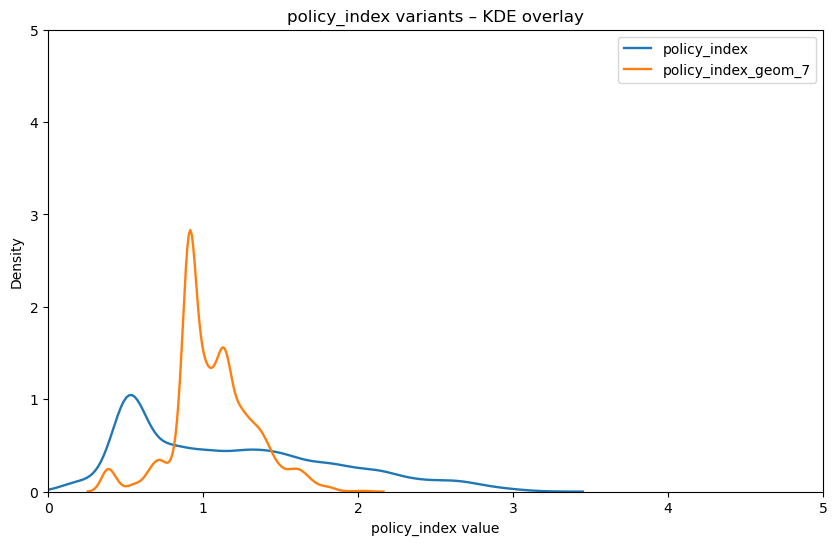

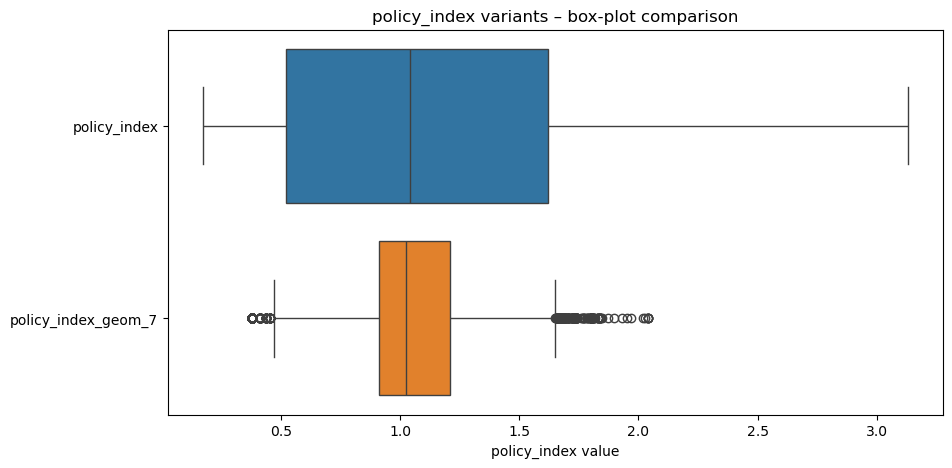

In [43]:
# After you’ve added the five CPSI variants to iea_scored_cpsi:
compare_policy_index_distributions(iea_scored_cpsi)

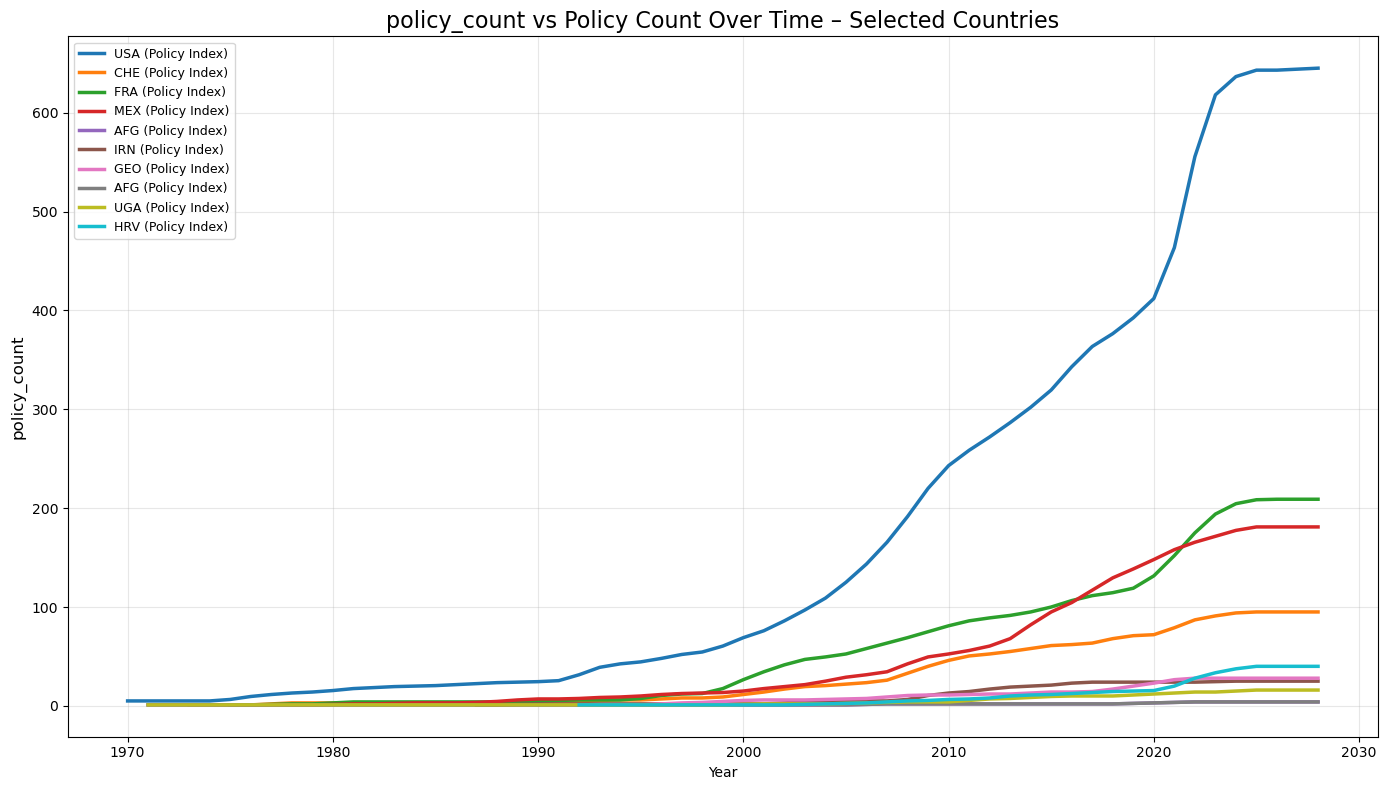

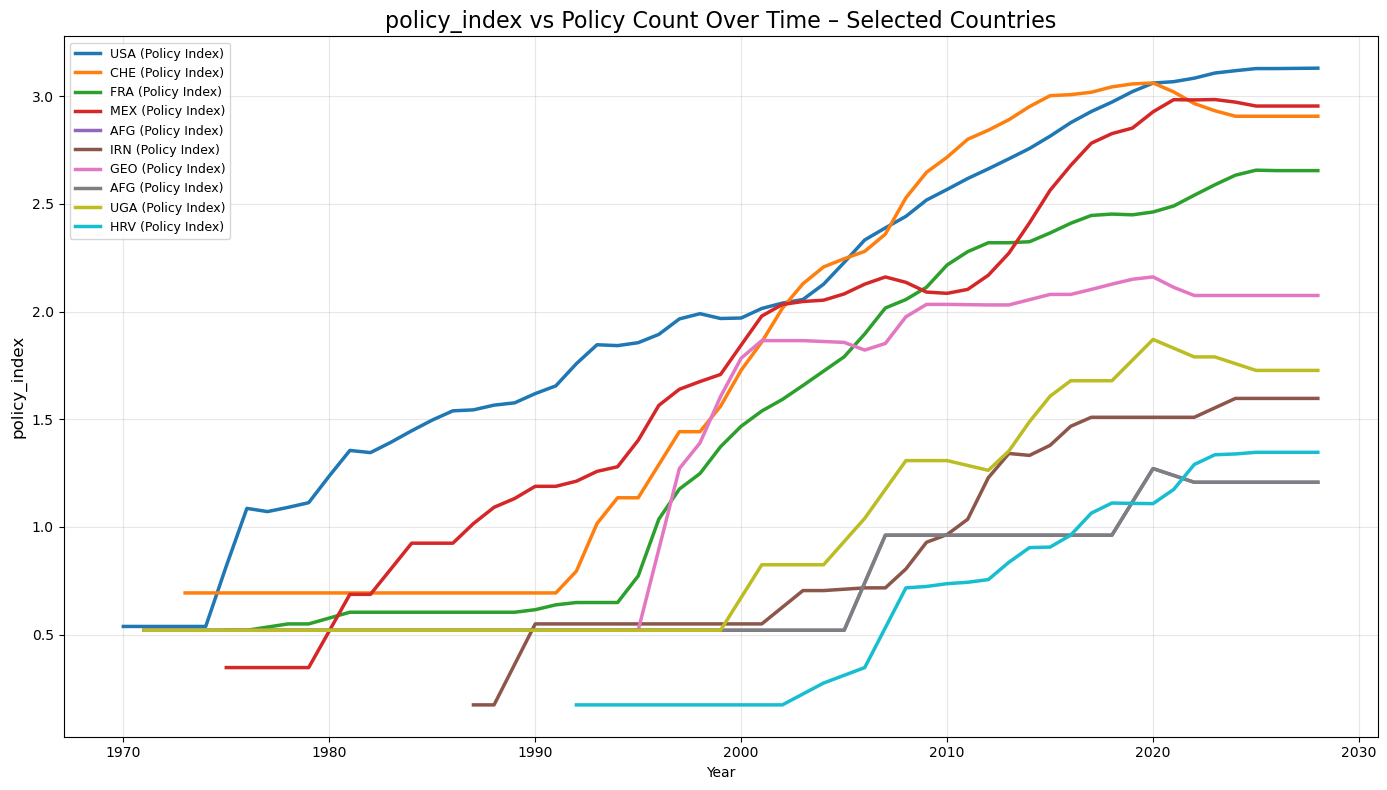

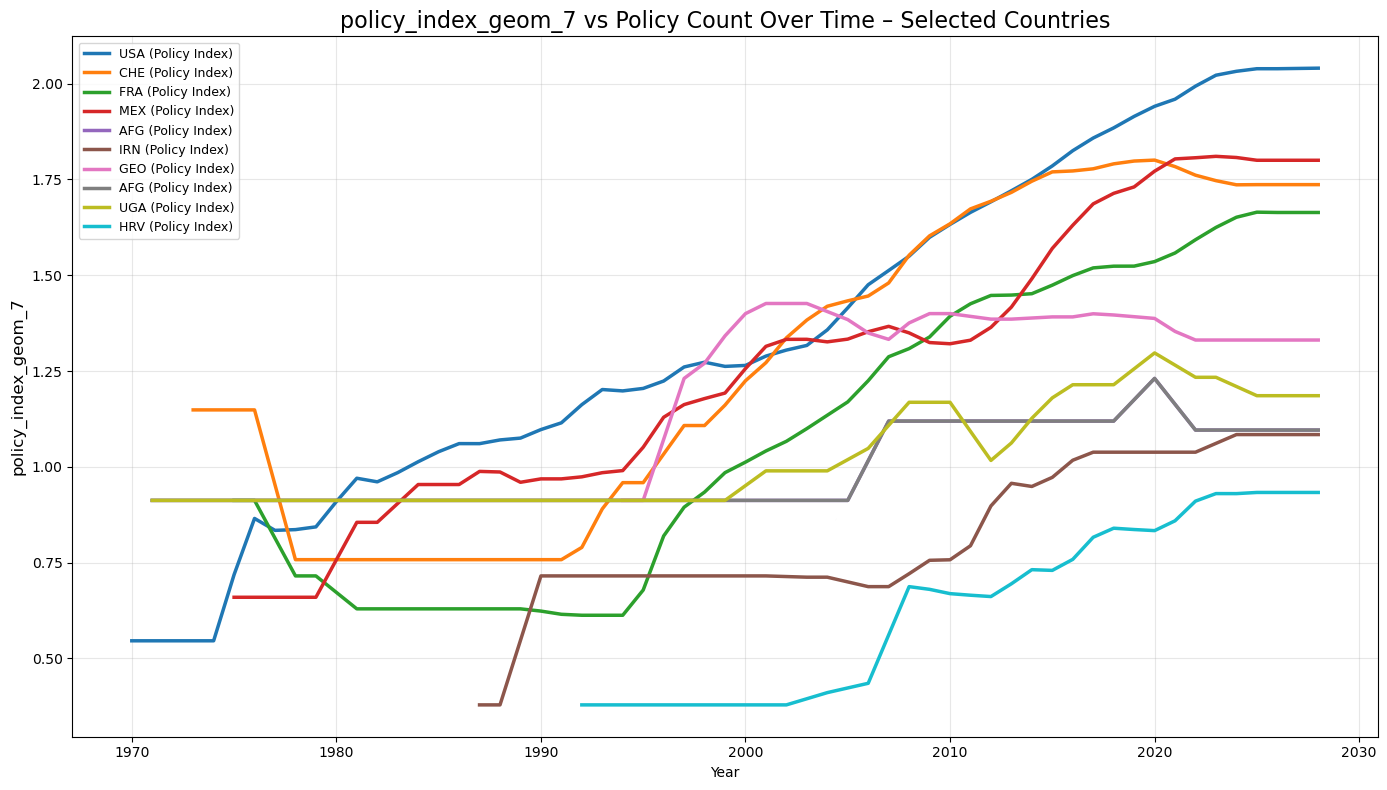

In [51]:
countries_to_analyze = ['USA', 'CHE', 'FRA', 'MEX', 'AFG', 'IRN', 'GEO', 'AFG', 'UGA', 'HRV']
for col in ["policy_count", "policy_index", "policy_index_geom_7"]:
    try:
        plot_index_and_policy_trend(iea_scored_cpsi, countries_to_analyze, index_col=col, policy_count_col='policy_count', year_col='year')
    except Exception as e:
        print(f"Error plotting {col} for countries {countries_to_analyze}: {e}")
        continue

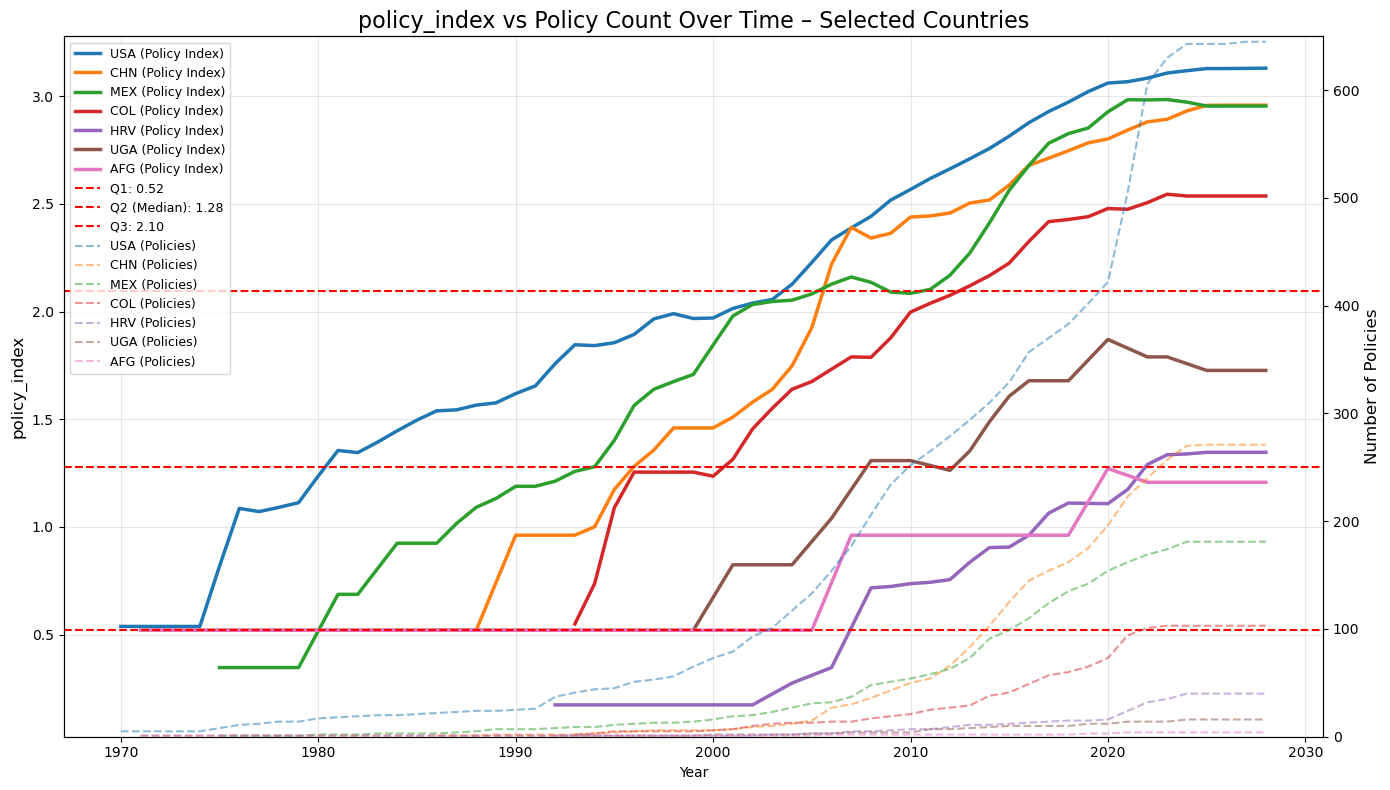

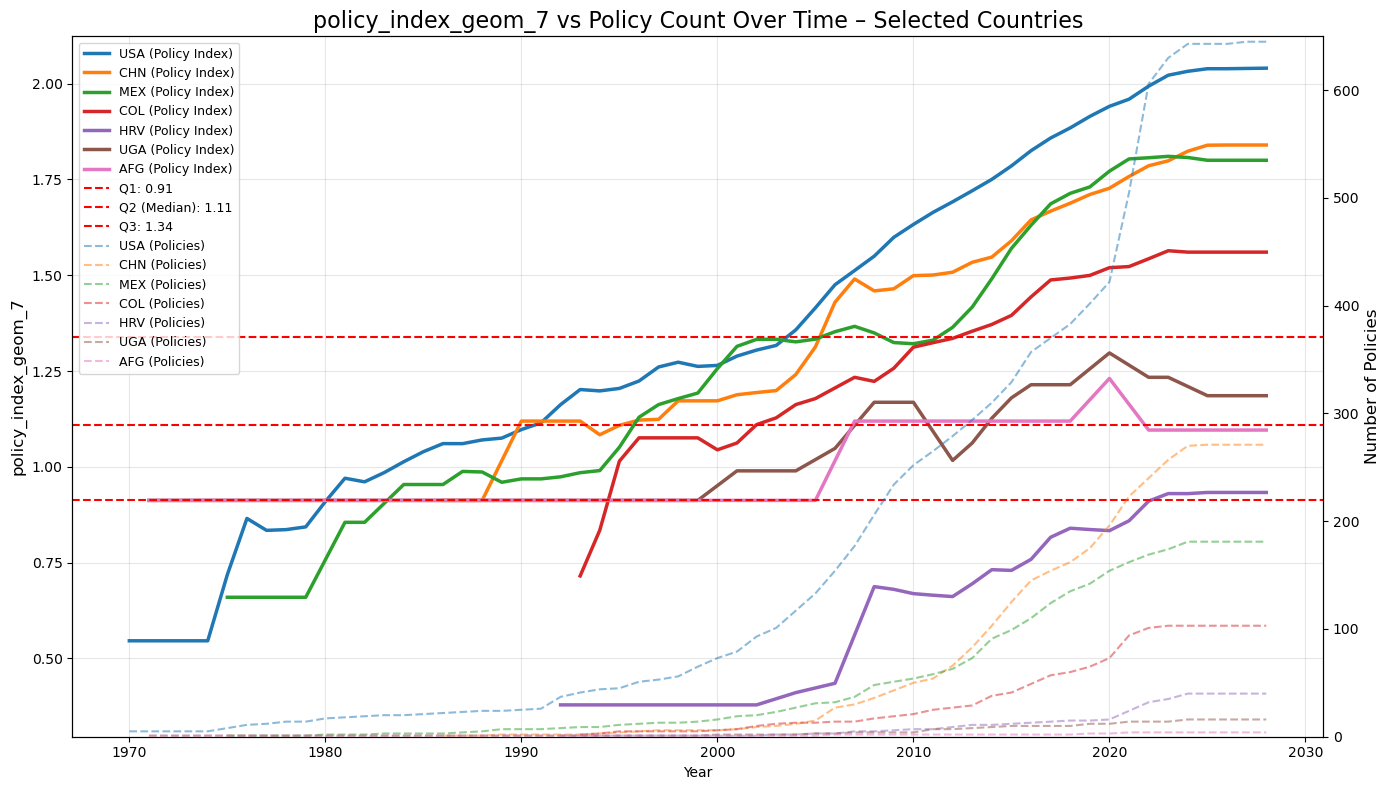

In [52]:
countries_to_analyze = ['USA', 'CHN', 'MEX', 'COL', 'HRV', 'UGA', 'AFG']
index_col_names = [col for col in iea_scored_cpsi.columns if col.startswith('policy_index')]
# for col in index_col_names:
for col in ["policy_index", "policy_index_geom_7"]:
    try:
        plot_index_and_policy_trend(iea_scored_cpsi, countries_to_analyze, index_col=col, policy_count_col='policy_count', year_col='year', show_policy_count=True, quartiles=True)
    except Exception as e:
        print(f"Error plotting {col} for countries {countries_to_analyze}: {e}")
        continue

In [53]:
iea_scored_policies

,country,iso_alpha_3,year,jurisdiction,type,topic,description,category,policy_score,topic_theme_14_refined,category_theme_27
0,Afghanistan,AFG,1971,International,"Free trade agreement,Trade policies","Transport,Buildings,Power",The EU Generalised Scheme of Preferences (GSP)...,"Heat pumps,Electric light-duty vehicles,Batter...",0.75,Energy,Solar Power
1,Afghanistan,AFG,1972,International,"Free trade agreement,Trade policies","Transport,Buildings,Power",The EU Generalised Scheme of Preferences (GSP)...,"Heat pumps,Electric light-duty vehicles,Batter...",0.75,Energy,Solar Power
2,Afghanistan,AFG,1973,International,"Free trade agreement,Trade policies","Transport,Buildings,Power",The EU Generalised Scheme of Preferences (GSP)...,"Heat pumps,Electric light-duty vehicles,Batter...",0.75,Energy,Solar Power
3,Afghanistan,AFG,1974,International,"Free trade agreement,Trade policies","Transport,Buildings,Power",The EU Generalised Scheme of Preferences (GSP)...,"Heat pumps,Electric light-duty vehicles,Batter...",0.75,Energy,Solar Power
4,Afghanistan,AFG,1975,International,"Free trade agreement,Trade policies","Transport,Buildings,Power",The EU Generalised Scheme of Preferences (GSP)...,"Heat pumps,Electric light-duty vehicles,Batter...",0.75,Energy,Solar Power
...,...,...,...,...,...,...,...,...,...,...,...
149901,Zimbabwe,ZWE,2028,National,NaN,NaN,The Act allowed for the establishment of the R...,NaN,0.25,Cross-cutting / Economy-wide,Other
149902,Zimbabwe,ZWE,2028,National,NaN,NaN,The ZERA board issues and withdraws licences ...,NaN,0.25,Cross-cutting / Economy-wide,Other
149903,Zimbabwe,ZWE,2028,National,NaN,NaN,The Electricity Act provided for the establish...,NaN,0.75,Cross-cutting / Economy-wide,Other
149904,Zimbabwe,ZWE,2028,International,"Free trade agreement,Trade policies","Transport,Buildings,Power",The EU - Eastern and Southern Africa States Ec...,"Heat pumps,Electric light-duty vehicles,Batter...",0.75,Energy,Solar Power


In [54]:
# Save final datasets
iea_scored_policies.to_csv(os.path.join(PROCESSED_DATA_DIR_PATH, 'IEA_scored_policies.csv'), index=False)
iea_scored_cpsi.to_csv(os.path.join(PROCESSED_DATA_DIR_PATH, 'IEA_scored_index.csv'), index=False)